(25000,) (25000,)
218
189
[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]
[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]
239.00925 178.0


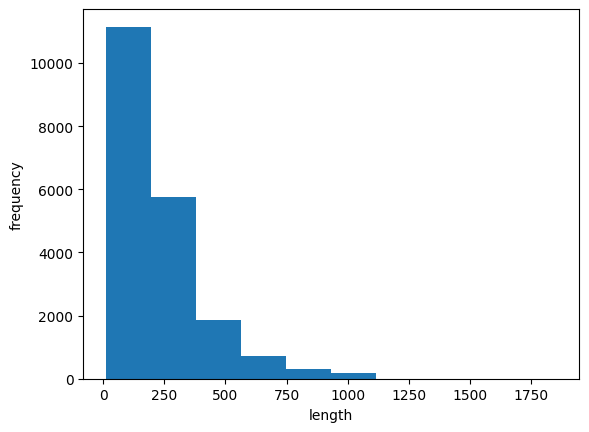

(20000, 100)
[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]
[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]
[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


In [ ]:
# IMDB리뷰 데이터 셋은 원래 영어로 된 문장이지만
# 케라스에 이미 정수로 바꾼 데이터가 존재한다.
from tensorflow.keras.datasets import imdb
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=200) # 자주 등장하는 단어 200개

print(train_input.shape, test_input.shape)
# 첫번째 리뷰의 길이
print(len(train_input[0])) # 218개의 토큰
# 두번째 리뷰의 길이
print(len(train_input[1])) # 189개의 토큰
# 첫번째 리뷰에 담긴 내용
print(train_input[0]) # 정수로 변환되어 있음
# 타겟 데이터
print(train_target[:20]) # 0 부정, 1 긍정

# 검증 세트 만들기
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)
# 리뷰 길이의 평균과 중간값
import numpy as np
lengths = np.array([len(x) for x in train_input])
print(np.mean(lengths), np.median(lengths))
# 길이 배열을 히스토그램으로
import matplotlib.pyplot as plt
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()
# 대부분의 리뷰가 짧으므로 100개 단어만 사용
# 100개 단어보다 짧은 리뷰는 0으로 패딩해줌.
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
# 훈련 시퀀스 크기
print(train_seq.shape)
# 훈련 시퀀스에 있는 첫번째 샘플
print(train_seq[0])
# 앞부분이 잘렸는지 뒷부분이 잘렸는지 확인
print(train_input[0][-10:]) # 앞부분이 잘린것을 확인가능함.
# 훈련 시퀀스에 있는 여섯번째 샘플
print(train_seq[5]) # 패딩이 앞부분에 추가된것을 확인가능함.
# 검증 세트도 최대 단어 100개로 맞춰줌
val_seq = pad_sequences(val_input, maxlen=100)

In [ ]:
# 순환 신경망 만들기

import keras
model = keras.Sequential()
# 샘플의 길이 100, 토큰을 원-핫 인코딩으로 변환했을때 차원 200
model.add(keras.layers.Input(shape=(100,200)))
model.add(keras.layers.SimpleRNN(8)) # 사용할 뉴런의 개
model.add(keras.layers.Dense(1, activation='sigmoid'))
# 원-핫 인코딩된 배열 자동으로 반환해주는 함수 활용
# 훈련 시퀀스를 원-핫 인코딩으로 변환
train_oh = keras.utils.to_categorical(train_seq)
print(train_oh.shape) # 정수 하나하나마다 200차원의 배열로 변경
# 첫번째 샘플의 토큰 10이 잘 인코딩되었는지 확인
print(train_oh[0][0][:12])
# 1인 원소가 하나인지 확인
print(np.sum(train_oh[0][0]))
# 검증 시퀀스도 변환
val_oh = keras.utils.to_categorical(val_seq)
model.summary()

(20000, 100, 200)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
1.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.4961 - loss: 0.6979 - val_accuracy: 0.5192 - val_loss: 0.6910
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5412 - loss: 0.6876 - val_accuracy: 0.5610 - val_loss: 0.6817
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6008 - loss: 0.6679 - val_accuracy: 0.5660 - val_loss: 0.7144
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.6108 - loss: 0.6608 - val_accuracy: 0.6744 - val_loss: 0.6154
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6893 - loss: 0.6006 - val_accuracy: 0.6806 - val_loss: 0.6022
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6961 - loss: 0.5911 - val_accuracy: 0.6778 - val_loss: 0.6030
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6965 - loss: 0.5885 - val_accuracy: 0.6878 - val_loss: 0.5972
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7051 - loss: 0.5822 

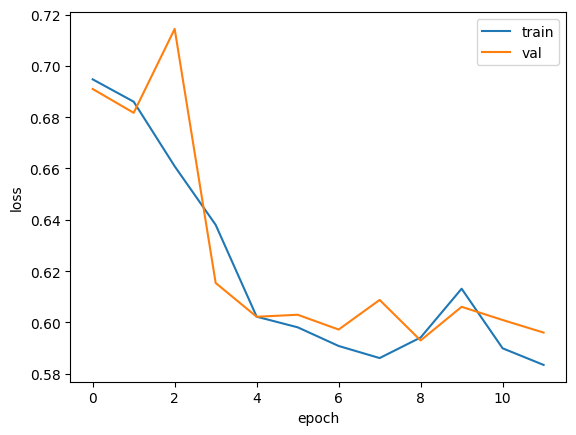

In [ ]:
# 순환 신경망 훈련하기

# Adam 옵티마이저 사용, 손실함수로 이진 크로스엔트로피 사용
# 에포크 100회, 배치크기 64, 체크포인트 등 합성공 신경망과 훈련 동일
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64,
                    validation_data=(val_oh, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])
# 열세번째 에포크에서 조기종료, 정확도 73%
# 훈련 손실과 검증 손실 그래프 그리기
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.5689 - loss: 0.6759 - val_accuracy: 0.6368 - val_loss: 0.6352
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7327 - loss: 0.5644 - val_accuracy: 0.7514 - val_loss: 0.5239
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7623 - loss: 0.5069 - val_accuracy: 0.7614 - val_loss: 0.4969
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7816 - loss: 0.4743 - val_accuracy: 0.7566 - val_loss: 0.5011
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7987 - loss: 0.4502 - val_accuracy: 0.7670 - val_loss: 0.4901
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7983 - loss: 0.4427 - val_accuracy: 0.7700 - val_loss: 0.4883
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8109 - loss: 0.4249 - val_accuracy: 0.7520 - val_loss: 0.5057
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8084 - loss: 0.4296 

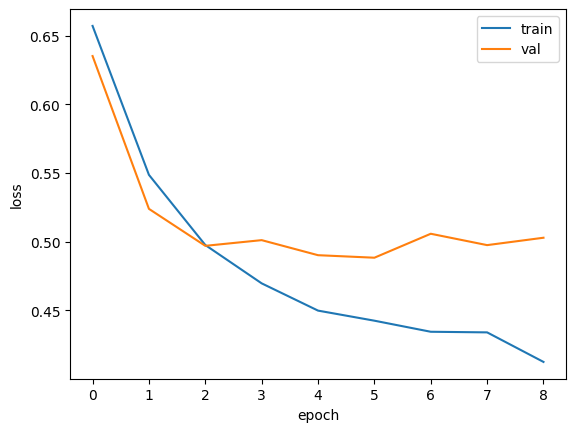

In [ ]:
# 단어 임베딩 사용

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)
# 단어 임베딩 추가한 순환 신경망
model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500,16))
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))
model_emb.summary()
# 모델 훈련
model_emb.compile(optimizer='adam', loss='binary_crossentropy',
               metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])
# 훈련 손실과 검증 손실 그래프로 출력
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()